In [5]:
import pandas as pd 
import numpy as np
import datetime
import yfinance as yf

In [6]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from skforecast.plot import set_dark_theme


In [7]:
#Modelling and Forecasting
import skforecast
import sklearn
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error


In [8]:
# warnings
# ==============================================================================
import warnings
from skforecast.exceptions import LongTrainingWarning
warnings.filterwarnings("once")
warnings.simplefilter('ignore', category=LongTrainingWarning)


In [9]:
# Download historical data for Apple
start='2015-05-05'
end='2025-05-15'


# Download historical data for Apple
data_ = yf.download('AAPL', start=start, end=end)

# Fetch the current number of shares outstanding using the Ticker object
ticker = yf.Ticker('AAPL')
shares_outstanding = ticker.info.get('sharesOutstanding', None)

if shares_outstanding:
    # Calculate the historical market cap
    data_['Market Cap'] = data_['Close'] * shares_outstanding
else:
    print("Shares outstanding data is not available.")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [10]:
# convert data into a  pandas dataframe
data = pd.DataFrame(data_)

#remove second index from the columns
data.columns = data.columns.droplevel(1)

#rename columns
data.columns = ['Close', 'High', 'Low', 'Open',  'Volume', 'Market Cap']
# set the index to the date
data.index = pd.to_datetime(data.index)
# show the first few rows of the dataframe
data.head()

# show the first few rows of the dataframe
data.tail()


,Close,High,Low,Open,Volume,Market Cap
Date,,,,,,
2025-05-08,197.231369,199.788014,194.425036,197.461064,50478900,2.945808e+12
2025-05-09,198.270004,200.277366,197.281295,198.739390,36453900,2.961321e+12
2025-05-12,210.789993,211.270004,206.750000,210.970001,63775800,3.148317e+12
2025-05-13,212.929993,213.399994,209.000000,210.429993,51909300,3.180280e+12
2025-05-14,212.330002,213.940002,210.580002,212.429993,49325800,3.171318e+12


In [11]:
# Interactive candlestick chart with Plotly
# ==============================================================================
candlestick = go.Candlestick(
    x=data.index,
    open=data.Open,
    close=data.Close,
    low=data.Low,
    high=data.High,
    name='Candlestick',
    increasing_line_color='green',
    decreasing_line_color='red',
)

fig = go.Figure(data=[candlestick])

fig.update_layout(
width=750,
height=350,

title=dict(text="<b>Close Price Chart</b>", font=dict(size=20)),
yaxis_title=dict(text="Price (USD)", font=dict(size=15)),
margin=dict(l=10, r=20, t=80, b=20),

    xaxis_rangeslider_visible=False,
)

fig.show()


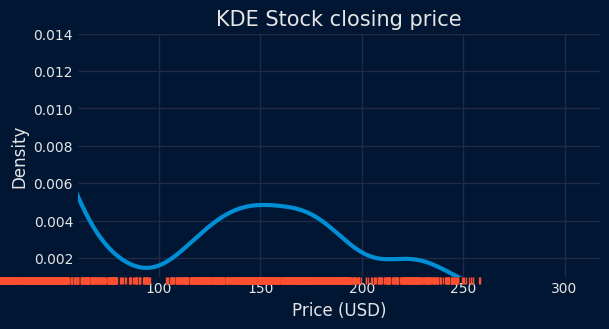

In [12]:
# KDE distribution of Bitcoin closing price
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 3))
p = sns.kdeplot(data=data, x='Close', linewidth=3, ax=ax)
r = sns.rugplot(data=data, x='Close', ax=ax, height=-.03, clip_on=False)
p.set(xlim=(60, None))
p.set_ylim(0.001, 0.014)
p.set_title('KDE Stock closing price', fontsize=15)
p.set_xlabel('Price (USD)');

In [13]:
# PRICE PER YEAR
#Locate corresponding data for each year
# ==============================================================================
years = list(data.index.year.unique())
df_plot = pd.DataFrame()

for year in years:

    year_open = data.loc[data.index.year == year, "Open"].iloc[0]
    year_close = data.loc[data.index.year == year, "Close"].iloc[-1]
    year_low = data.loc[data.index.year == year, "Low"].min()
    year_high = data.loc[data.index.year == year, "High"].max()

    df_plot[year] = pd.Series([year_open, year_close, year_low, year_high])

df_plot = df_plot.T
df_plot = df_plot.set_axis(["Open", "Close", "Low", "High"], axis=1)

# Calculate % change between the open and close price of the year
# ==============================================================================
df_plot["year_change"] = 100 * (df_plot["Close"] - df_plot["Open"]) / df_plot["Open"]
df_plot.head(3)

,Open,Close,Low,High,year_change
2015,28.581958,23.782825,20.698214,29.780874,-16.790775
2016,23.184080,26.751020,20.448615,27.273882,15.385299
2017,26.746401,39.715729,26.506191,41.586168,48.489994


In [14]:
# Create a list of dicts with the % change annotations for the plot
# ==============================================================================
annotations_list = []
max_high = df_plot["High"].max()

for year in years:

    df_aux = df_plot.loc[df_plot.index == year,]
    loc_x = pd.to_datetime(df_aux.index[0], format="%Y")
    loc_y = df_aux["High"].values[0] / max_high + 0.05
    text = "{:.1f}%".format(df_aux["year_change"].values[0])

    annotation = dict(
        x=loc_x,
        y=loc_y,
        xref="x",
        yref="paper",
        showarrow=False,
        xanchor="center",
        text=text,
    )

    annotations_list.append(annotation)

In [15]:
# Interactive candlestick chart with Plotly
# ==============================================================================
candlestick = go.Candlestick(
    x=pd.to_datetime(df_plot.index, format="%Y"),
    open=df_plot.Open,
    close=df_plot.Close,
    low=df_plot.Low,
    high=df_plot.High,
)

fig = go.Figure(data=[candlestick])

fig.update_layout(
    width=750,
    height=350,
    title=dict(text="<b>Stock yearly chart</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=13)),
    margin=dict(l=0, r=20, t=55, b=20),
    xaxis_rangeslider_visible=False,
    annotations=annotations_list,
)

fig.show()

In [16]:
# Locate corresponding data for each month
# ==============================================================================
years = list(data.index.year.unique())
df_plot = pd.DataFrame()

for year in years:
    for month in range(12):

        start_date = pd.to_datetime(f"{year}-{month+1}-01", format="%Y-%m-%d")
        end_date = start_date + pd.offsets.MonthBegin()
        mask = (data.index >= start_date) & (data.index < end_date)

        if not data.loc[mask, :].empty:

            month_open = data.loc[mask, "Open"].iloc[0]
            month_close = data.loc[mask, "Close"].iloc[-1]
            month_low = data.loc[mask, "Low"].min()
            month_high = data.loc[mask, "High"].max()

            serie = pd.Series([month_open, month_close, month_low, month_high])
            df_aux = pd.DataFrame(serie, columns=[f"{str(month+1).zfill(2)}-{year}"])

            if df_plot.empty:
                df_plot = df_aux.copy()
            else:
                df_plot = pd.concat([df_plot, df_aux], axis=1)

df_plot = df_plot.T
df_plot = df_plot.set_axis(["Open", "Close", "Low", "High"], axis=1)


In [17]:
# Boxplot chart for annual seasonality
# ==============================================================================




df_plot["month"] = pd.to_datetime(df_plot.index, format="%m-%Y").month

# fig 1 monthly boxplot
fig1 = px.box(
    df_plot.sort_values("month"),
    x="month",
    y="Close",
)

# fig 2 line with median data for each month
df_median = pd.DataFrame(df_plot.groupby("month")["Close"].median()).reset_index()
fig2 = px.line(
    df_median,
    x="month",
    y="Close",
    markers=True,
)

fig = go.Figure(data=fig1.data + fig2.data)

fig.update_layout(
    width=650,
    height=350,
    title=dict(text="<b>Stock Price per month</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=13)),
    xaxis=dict(tickmode="linear"),
    xaxis_title=dict(text="month", font=dict(size=13)),
    margin=dict(l=0, r=20, t=55, b=20),
)

fig.show()



/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:2596: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:2596: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [18]:
# Boxplot chart for monthly seasonality
# ==============================================================================
data["day"] = pd.Series(data.index).dt.day.values

# fig 1 dayly boxplot
fig1 = px.box(data.sort_values("day"), x="day", y="Close")

# fig 2 line with median data for each day
df_median = pd.DataFrame(data.groupby("day")["Close"].median()).reset_index()
fig2 = px.line(df_median, x="day", y="Close", markers=True)

fig = go.Figure(data=fig1.data + fig2.data)

fig.update_layout(
    width=750,
    height=350,
    title=dict(text="<b>Stock Price per day of the month</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=13)),
    xaxis=dict(tickmode="linear", tickangle=0, range=[0.5, 31.5]),
    xaxis_title=dict(text="day", font=dict(size=13)),
    margin=dict(l=0, r=20, t=55, b=20),
)

fig.show()

/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:2596: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:2596: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [19]:
# Boxplot chart for weekly seasonality
# ==============================================================================
data["weekday"] = data.index.day_of_week + 1

# fig 1 weekly boxplot
fig1 = px.box(data.sort_values("weekday"), x="weekday", y="Close")

# fig 2 line with median data for each weekday
df_median = pd.DataFrame(data.groupby("weekday")["Close"].median()).reset_index()
fig2 = px.line(df_median, x="weekday", y="Close", markers=True)

fig = go.Figure(data=fig1.data + fig2.data)

fig.update_layout(
    width=600,
    height=300,
    title=dict(text="<b>Stock Price per day of the week</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=13)),
    xaxis=dict(tickmode="linear"),
    xaxis_title=dict(text="weekday", font=dict(size=13)),
    margin=dict(l=0, r=20, t=55, b=20),
)

fig.show()

/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:2596: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:2596: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



Autocorrelation plots

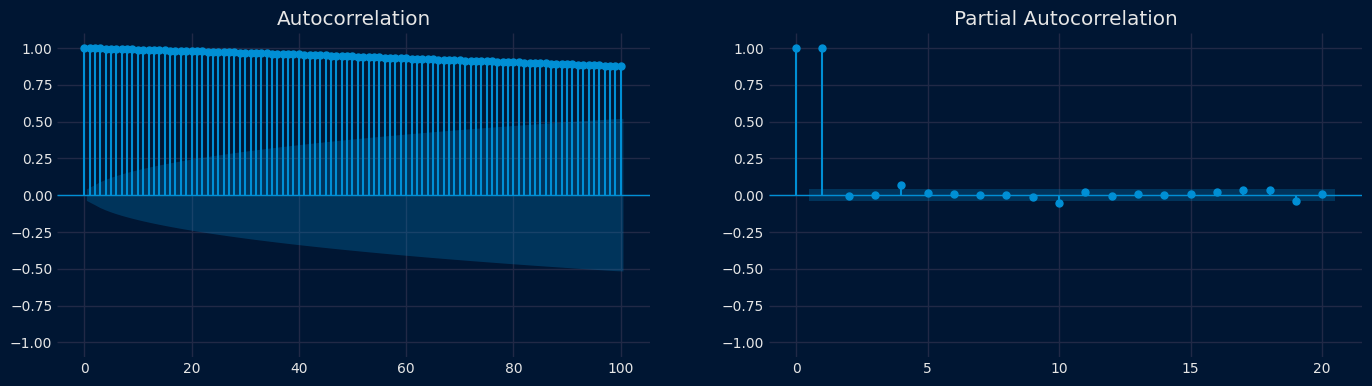

In [20]:
# Autocorrelation plots
# ==============================================================================
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
axes = axes.flat
plot_acf(data.Close, ax=axes[0], linewidth = 1, lags=100)
axes[0].set_ylim(-1.1, 1.1)
plot_pacf(data.Close, ax=axes[1], lags=20, method='ywm',  linewidth = 1)
axes[1].set_ylim(-1.1, 1.1)
plt.show()

Baseline - Random walk simulation

When generating a predictive model, it is convenient to identify a base model, or baseline, on which to compare each of the proposed iterations or models. In the case of finance, according to random walk theory, market prices behave randomly and not as a function of their time series. Thus, the best estimate of the value 
tn+1 is the value tn plus an unpredictable change.

Although a broad time series is available, it presents periods with highly differentiated prices, as determined in the graphical exploration. Only data from the last two years are used.

In [21]:
# Selection of train-test dates
# ==============================================================================

# Select the start and end dates for the training and testing periods
end_ = pd.to_datetime(end) + pd.DateOffset(days=1)
end_train = end_ - pd.DateOffset(years=1)
start_train = end_train - pd.DateOffset(years=3)

print(f"Complete time series : {data.index.min()} --- {data.index.max()}  (n={len(data)})")
print(f"Train dates          : {data.loc[start_train:end_train].index.min()} --- {data.loc[start_train:end_train].index.max()}  (n={len(data.loc[start_train:end_train])})")
print(f"Test dates           : {data.loc[end_train:].index.min()} --- {data.loc[end_train:].index.max()}  (n={len(data.loc[end_train:])})")

Complete time series : 2015-05-05 00:00:00 --- 2025-05-14 00:00:00  (n=2523)
Train dates          : 2021-05-17 00:00:00 --- 2024-05-16 00:00:00  (n=756)
Test dates           : 2024-05-16 00:00:00 --- 2025-05-14 00:00:00  (n=249)


In [22]:
# Random walk simulation
# ==============================================================================
df_rw = data[['Close']].copy()
df_rw['pred_close'] = df_rw['Close'].shift(1)

# Test error
# ==============================================================================
y_true = df_rw.loc[end_train:, 'Close']
y_pred = df_rw.loc[end_train:, 'pred_close']
metric = mean_absolute_error(y_true, y_pred)

print(f'Test error: {metric}')
display(df_rw.loc[end_train:,].head(4))

Test error: 2.888480067731865


,Close,pred_close
Date,,
2024-05-16,188.956314,188.836868
2024-05-17,188.986176,188.956314
2024-05-20,190.150711,188.986176
2024-05-21,191.454636,190.150711


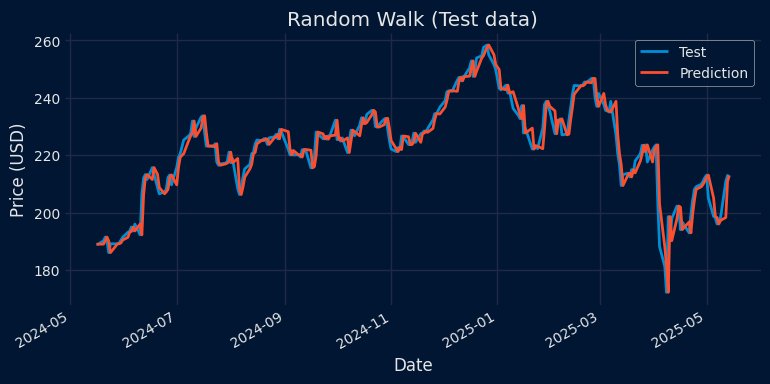

In [23]:
# Plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 4))
df_rw.loc[end_train:, 'Close'].plot(ax=ax, linewidth=2, label='Test')
df_rw.loc[end_train:, 'pred_close'].plot(ax=ax, linewidth=2, label='Prediction')
ax.set_title('Random Walk (Test data)')
ax.set_ylabel('Price (USD)')
ax.legend();

In [24]:
# DataFrame models' test error
# ==============================================================================
df_errors = pd.DataFrame({
                'model': 'Base - Random Walk',
                'lags': 1, 
                'test_error': metric,
                'exog_variables': False
                },
                index=[0]
            )
df_errors

,model,lags,test_error,exog_variables
0,Base - Random Walk,1,2.88848,False


Recursive autoregressive forecaster

An Autoregressive Forecaster (ForecasterRecursive) with a LightGBM regressor, an implementation of the Gradient Boosting algorithm developed by Microsoft that usually achieves excellent results, is used to model price.

Previous sections show an absence of autocorrelation beyond the first lag. One way to verify this is to train several models with an increasing amount of lags and check if the error doesn't reduce. This approach can be done by backtesting, using steps = 1 (predict only the next value in the series, 
tn+1) it reproduces the random walk model methodology.

In [25]:
from skforecast.recursive import ForecasterRecursive

In [27]:
# Ensure unique indices
data = data[~data.index.duplicated(keep='first')]

# Prepare y series with a proper frequency
y = data.loc[start_train:, 'Close'].copy()
y.index = pd.to_datetime(y.index)  # Ensure datetime format
y = y.asfreq('B', method='pad')  # Set frequency to business days and fill missing values

# Forecasters backtest with different lags
lags = [1, 7, 30]
metrics = []
predictions_list = []

for lag in lags:
    forecaster = ForecasterRecursive(
        regressor=LGBMRegressor(random_state=123, verbose=-1),
        lags=lag,
        transformer_y=None
    )
    
    cv = TimeSeriesFold(
        steps=1,
        initial_train_size=len(data.loc[start_train:end_train, 'Close']),
        fixed_train_size=True,
        refit=True,
    )
    
    metric, predictions = backtesting_forecaster(
        forecaster=forecaster,
        y=y,  # Pass the corrected y series
        cv=cv,
        metric='mean_absolute_error',
        verbose=False,
        show_progress=True,
    )
    
    metrics.append(metric.iloc[0]['mean_absolute_error'])
    predictions_list.append(predictions)

  0%|          | 0/287 [00:00<?, ?it/s]

  0%|          | 0/287 [00:00<?, ?it/s]

  0%|          | 0/287 [00:00<?, ?it/s]

In [29]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot actual test data
fig.add_trace(go.Scatter(
    x=data.loc[end_train:].index,
    y=data.loc[end_train:, 'Close'],
    mode='lines',
    name='Test'
))

# Plot predictions for each lag
for predictions, lag in zip(predictions_list, lags):
    fig.add_trace(go.Scatter(
        x=predictions.index,
        y=predictions['pred'],
        mode='lines',
        name=f'Prediction, {lag} lags'
    ))

fig.update_layout(
    title='Close Price vs Predictions (Test Data)',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    width=800,
    height=400
)

fig.show()

In [30]:
# DataFrame models' test error
# ==============================================================================
model = 'LGBMRegressor'
df_errors = pd.concat([
                df_errors,
                pd.DataFrame({
                    'model': model,
                    'lags': lags, 
                    'test_error': metrics,
                    'exog_variables': False
                })
             ]).reset_index(drop=True)
df_errors.sort_values(by='test_error')

,model,lags,test_error,exog_variables
0,Base - Random Walk,1,2.888480,False
3,LGBMRegressor,30,4.336633,False
2,LGBMRegressor,7,4.461763,False
1,LGBMRegressor,1,4.731290,False


Forecasting with exogenous variables

In the previous example, only lags of the predicted variable itself have been used as predictors. In some scenarios, it is possible to have information about other variables, whose future value is known, and which can serve as additional predictors in the model. Typical examples are:

Holidays (local, national...)

Month of the year

Day of the week

Time of day

For this case, it is used the variables resulting from the, after studying seasonality, the month of the year.

In [32]:
# One hot encoding categorical variables
# ==============================================================================
data['month'] = data.index.month
data = pd.get_dummies(data, columns=['month'], dtype=int)
data.head(2)

,Close,High,Low,Open,Volume,Market Cap,day,weekday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
Date,,,,,,,,,,,,,,,,,,,,
2015-05-05,28.057827,28.648869,28.053365,28.581958,197085600,4.190661e+11,5,2,0,0,0,0,1,0,0,0,0,0,0,0
2015-05-06,27.881634,28.269715,27.513625,28.227337,288564000,4.164345e+11,6,3,0,0,0,0,1,0,0,0,0,0,0,0


In [33]:
exog = [column for column in data.columns if column.startswith(('month'))]
exog

['month_1',
 'month_2',
 'month_3',
 'month_4',
 'month_5',
 'month_6',
 'month_7',
 'month_8',
 'month_9',
 'month_10',
 'month_11',
 'month_12']

In [36]:
## Ensure unique indices
data = data[~data.index.duplicated(keep='first')]

# Prepare y series with a proper frequency
y = data.loc[start_train:, 'Close'].copy()
y.index = pd.to_datetime(y.index)  # Ensure datetime format
y = y.asfreq('B', method='pad')  # Set frequency to business days and fill missing values

# Prepare exogenous variables with a proper frequency
exog = data.loc[start_train:, [col for col in data.columns if col.startswith('month')]].copy()
exog.index = pd.to_datetime(exog.index)  # Ensure datetime format
exog = exog.asfreq('B', method='pad')  # Set frequency to business days and fill missing values

# Forecaster backtest with exogenous variables
forecaster = ForecasterRecursive(
    regressor=LGBMRegressor(random_state=123, verbose=-1),
    lags=1,
    transformer_y=None,
    transformer_exog=None
)

# Backtest test data, 1 step
metric, predictions = backtesting_forecaster(
    forecaster=forecaster,
    y=y,
    exog=exog,
    cv=cv,
    metric='mean_absolute_error',
    verbose=False,
    show_progress=True
)

  0%|          | 0/287 [00:00<?, ?it/s]

In [37]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot actual test data
fig.add_trace(go.Scatter(
    x=data.loc[end_train:].index,
    y=data.loc[end_train:, 'Close'],
    mode='lines',
    name='Test'
))

# Plot predictions 1 lag without exogenous variables
predictions_no_exog = predictions_list[0].rename(columns={'pred': 'Predictions, 1 lag'})
fig.add_trace(go.Scatter(
    x=predictions_no_exog.index,
    y=predictions_no_exog['Predictions, 1 lag'],
    mode='lines',
    name='Predictions, 1 lag'
))

# Plot predictions 1 lag with exogenous variables
predictions_exog = predictions.rename(columns={'pred': 'Predictions, 1 lag with exog'})
fig.add_trace(go.Scatter(
    x=predictions_exog.index,
    y=predictions_exog['Predictions, 1 lag with exog'],
    mode='lines',
    name='Predictions, 1 lag with exog'
))

fig.update_layout(
    title='Close Price vs Predictions (Test Data)',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    width=800,
    height=400
)

fig.show()

In [38]:
# DataFrame models' test error
# ==============================================================================
model = 'LGBMRegressor'
df_errors = pd.concat([
                df_errors,
                pd.DataFrame({
                    'model': model,
                    'lags': lags, 
                    'test_error': metrics,
                    'exog_variables': True
                })
             ]).reset_index(drop=True)
df_errors.sort_values(by='test_error')

,model,lags,test_error,exog_variables
0,Base - Random Walk,1,2.888480,False
3,LGBMRegressor,30,4.336633,False
6,LGBMRegressor,30,4.336633,True
2,LGBMRegressor,7,4.461763,False
5,LGBMRegressor,7,4.461763,True
1,LGBMRegressor,1,4.731290,False
4,LGBMRegressor,1,4.731290,True
